In [ ]:
import numpy as np
import pandas as pd
#import scipy.stats
import ast
import PyWGCNA
import os
from ast import literal_eval

In [ ]:
# MONKEY PATCH FOR READING WGCNA PICKLES

import anndata
import weakref

# Versions of some packages changed from when we generated pickles. We have to Monkey patch it to read it
# we override anndata's __setstate__ at runtimeto inject the missing "_adata_ref". This is ugly, but works

def fake_setstate(self, state):
    self.__dict__ = state.copy()
    self.__dict__["_adata_ref"] = weakref.ref(state.get("_adata_ref", self))

anndata._core.file_backing.AnnDataFileManager.__setstate__ = fake_setstate

In [ ]:
# Define colors
# Light version is obtained by setting alpha=0.5

ncolor  = '#00728eff' # solid dark
ncolor2 = '#00728e80' # alpha=0.5
lightncolor = '#7fb8c6ff' # solid light

tcolor  = '#ab3502ff'
tcolor2 = '#ab350280'
lighttcolor = '#d49980ff'

graycolor = '#4D4E4FFF'
graycolor2 ='#4d4e4f80'

lightgray = '#C8CAD4'

orangecolor = '#e69426'
orangecolor2 = '#e6942680'
lightorangecolor = '#f2c992ff'

# Same/Diff. Cell Type and Regulon

In [40]:
df = pd.read_csv('/home/lnemati/pathway_crosstalk/results/comparison/averages.csv')
df = df.query('value_type == "average_corr"')

df['interaction_type'].unique()

array(['ccc_lr_pairs.csv', 'mismatched_lr_pairs.csv', 'intact_direct.csv',
       'intact_physical.csv', 'intact_association.csv',
       'same_regulon.csv', 'different_regulon.csv', 'same_cell_type.csv',
       'different_cell_type.csv'], dtype=object)

In [41]:
df = pd.read_csv('/home/lnemati/pathway_crosstalk/results/comparison/averages.csv')
df = df.query('value_type == "average_corr"')

df['interaction_type'] = df.interaction_type.replace({ 
    'ccc_lr_pairs.csv': 'Same CCI',
    'mismatched_lr_pairs.csv': 'Diff. CCI',
    #'intact_direct.csv': 'IA Direct',
    #'intact_physical.csv': 'IA Physical',
    #'intact_association.csv': 'IA Association',
    'same_regulon.csv': 'Same Regulon',
    'different_regulon.csv': 'Diff. Regulon',
    'same_cell_type.csv': 'Same Cell Type',
    'different_cell_type.csv': 'Diff. Cell Type'
})

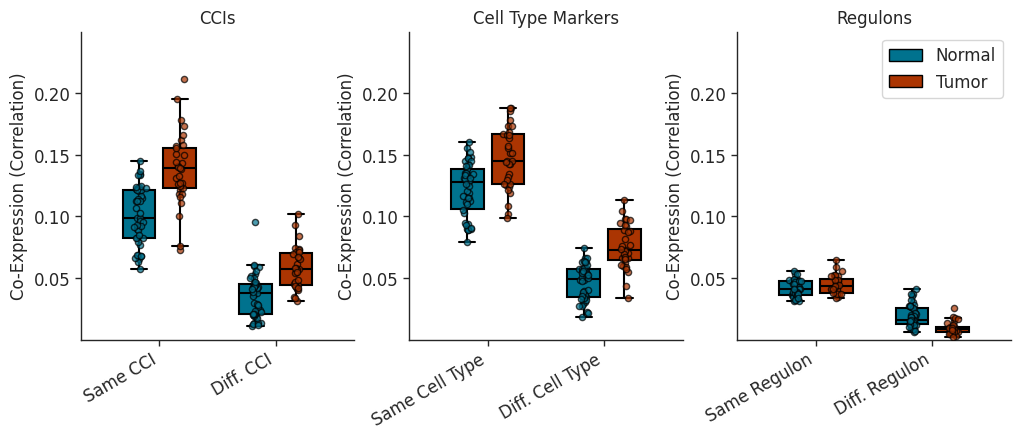

In [42]:
import matplotlib.pyplot as plt
import numpy as np

fs = 12

pairs = {
    'CCIs': ['Same CCI', 'Diff. CCI'],
    'Cell Type Markers': ['Same Cell Type', 'Diff. Cell Type'],
    'Regulons': ['Same Regulon', 'Diff. Regulon']
}

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=False)

for ax, (title, labels) in zip(axes, pairs.items()):
    
    sub = df[df['interaction_type'].isin(labels)]
    
    positions = [0, 1]
    width = 0.35
    
    for i, cond in enumerate(['normal', 'tumor']):
        cond_data = sub[sub['condition'] == cond]
        
        data = [
            cond_data[cond_data['interaction_type'] == labels[0]]['value'],
            cond_data[cond_data['interaction_type'] == labels[1]]['value']
        ]
        
        pos = np.array(positions) + (i - 0.5) * width
        
        bp = ax.boxplot(
            data,
            positions=pos,
            widths=width * 0.8,
            patch_artist=True,
            showfliers=False
        )
        
        color = ncolor if cond == 'normal' else tcolor
        
        for box in bp['boxes']:
            box.set(facecolor=color, edgecolor='k', linewidth=1.5)
        
        for element in ['whiskers', 'caps', 'medians']:
            for item in bp[element]:
                item.set(color='k', linewidth=1.5)
        
        # jittered points
        for j, vals in enumerate(data):
            x_jitter = np.random.normal(pos[j], 0.02, size=len(vals))
            ax.scatter(
                x_jitter, vals,
                color=color,
                edgecolor='k',
                s=20,
                alpha=0.7,
                zorder=3
            )
    
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, fontsize=fs, rotation=30, ha='right')
    
    ax.set_title(title, fontsize=fs)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=fs)

# Shared y-axis
for ax in axes:
    ax.set_ylabel('Co-Expression (Correlation)', fontsize=fs)
    ax.set_ylim(0., 0.25)
    ax.set_yticks([0.05, 0.1, 0.15, 0.2])
    ax.tick_params(axis='both', which='both', direction='out',
                   length=4, width=1,
                   bottom=True, top=False, left=True, right=False)
# Legend
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor=ncolor, edgecolor='k', label='Normal'),
    Patch(facecolor=tcolor, edgecolor='k', label='Tumor')
]
axes[-1].legend(handles=legend_handles, fontsize=fs, loc='upper right')

# Save the figure
plt.savefig('/home/lnemati/pathway_crosstalk/results/revision/images/same_diff_cci_ct_regulon.pdf', dpi=300, bbox_inches='tight')
plt.savefig('/home/lnemati/pathway_crosstalk/results/revision/images/same_diff_cci_ct_regulon.png', dpi=300, bbox_inches='tight')

plt.show()

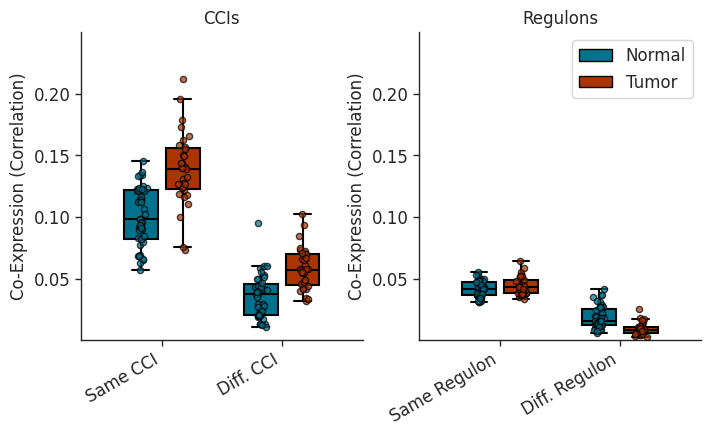

In [43]:
import matplotlib.pyplot as plt
import numpy as np

fs = 12

pairs = {
    'CCIs': ['Same CCI', 'Diff. CCI'],
    #'Cell Type Markers': ['Same Cell Type', 'Diff. Cell Type'],
    'Regulons': ['Same Regulon', 'Diff. Regulon']
}

fig, axes = plt.subplots(1, len(pairs), figsize=(4*len(pairs), 4), sharey=False)

for ax, (title, labels) in zip(axes, pairs.items()):
    
    sub = df[df['interaction_type'].isin(labels)]
    
    positions = [0, 1]
    width = 0.35
    
    for i, cond in enumerate(['normal', 'tumor']):
        cond_data = sub[sub['condition'] == cond]
        
        data = [
            cond_data[cond_data['interaction_type'] == labels[0]]['value'],
            cond_data[cond_data['interaction_type'] == labels[1]]['value']
        ]
        
        pos = np.array(positions) + (i - 0.5) * width
        
        bp = ax.boxplot(
            data,
            positions=pos,
            widths=width * 0.8,
            patch_artist=True,
            showfliers=False
        )
        
        color = ncolor if cond == 'normal' else tcolor
        
        for box in bp['boxes']:
            box.set(facecolor=color, edgecolor='k', linewidth=1.5)
        
        for element in ['whiskers', 'caps', 'medians']:
            for item in bp[element]:
                item.set(color='k', linewidth=1.5)
        
        # jittered points
        for j, vals in enumerate(data):
            x_jitter = np.random.normal(pos[j], 0.02, size=len(vals))
            ax.scatter(
                x_jitter, vals,
                color=color,
                edgecolor='k',
                s=20,
                alpha=0.7,
                zorder=3
            )
    
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, fontsize=fs, rotation=30, ha='right')
    
    ax.set_title(title, fontsize=fs)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=fs)

# Shared y-axis
for ax in axes:
    ax.set_ylabel('Co-Expression (Correlation)', fontsize=fs)
    ax.set_ylim(0., 0.25)
    ax.set_yticks([0.05, 0.1, 0.15, 0.2])
    ax.tick_params(axis='both', which='both', direction='out',
                   length=4, width=1,
                   bottom=True, top=False, left=True, right=False)
    
# Legend
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor=ncolor, edgecolor='k', label='Normal'),
    Patch(facecolor=tcolor, edgecolor='k', label='Tumor')
]
axes[-1].legend(handles=legend_handles, fontsize=fs, loc='upper right')

# Save the figure
plt.savefig('/home/lnemati/pathway_crosstalk/results/revision/images/same_diff_cci_regulon_no_ct.pdf', dpi=300, bbox_inches='tight')
plt.savefig('/home/lnemati/pathway_crosstalk/results/revision/images/same_diff_cci_regulon_no_ct.png', dpi=300, bbox_inches='tight')

plt.show()

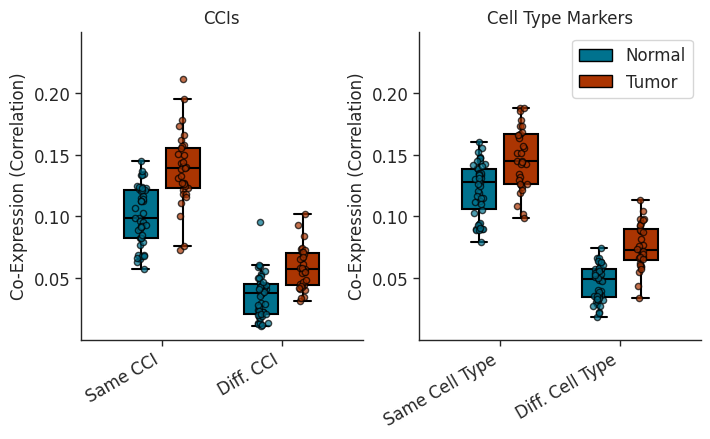

In [44]:
import matplotlib.pyplot as plt
import numpy as np

fs = 12

pairs = {
    'CCIs': ['Same CCI', 'Diff. CCI'],
    'Cell Type Markers': ['Same Cell Type', 'Diff. Cell Type'],
    #'Regulons': ['Same Regulon', 'Diff. Regulon']
}

fig, axes = plt.subplots(1, len(pairs), figsize=(4*len(pairs), 4), sharey=False)

for ax, (title, labels) in zip(axes, pairs.items()):
    
    sub = df[df['interaction_type'].isin(labels)]
    
    positions = [0, 1]
    width = 0.35
    
    for i, cond in enumerate(['normal', 'tumor']):
        cond_data = sub[sub['condition'] == cond]
        
        data = [
            cond_data[cond_data['interaction_type'] == labels[0]]['value'],
            cond_data[cond_data['interaction_type'] == labels[1]]['value']
        ]
        
        pos = np.array(positions) + (i - 0.5) * width
        
        bp = ax.boxplot(
            data,
            positions=pos,
            widths=width * 0.8,
            patch_artist=True,
            showfliers=False
        )
        
        color = ncolor if cond == 'normal' else tcolor
        
        for box in bp['boxes']:
            box.set(facecolor=color, edgecolor='k', linewidth=1.5)
        
        for element in ['whiskers', 'caps', 'medians']:
            for item in bp[element]:
                item.set(color='k', linewidth=1.5)
        
        # jittered points
        for j, vals in enumerate(data):
            x_jitter = np.random.normal(pos[j], 0.02, size=len(vals))
            ax.scatter(
                x_jitter, vals,
                color=color,
                edgecolor='k',
                s=20,
                alpha=0.7,
                zorder=3
            )
    
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, fontsize=fs, rotation=30, ha='right')
    
    ax.set_title(title, fontsize=fs)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=fs)

# Shared y-axis
for ax in axes:
    ax.set_ylabel('Co-Expression (Correlation)', fontsize=fs)
    ax.set_ylim(0., 0.25)
    ax.set_yticks([0.05, 0.1, 0.15, 0.2])
    ax.tick_params(axis='both', which='both', direction='out',
                   length=4, width=1,
                   bottom=True, top=False, left=True, right=False)
    
# Legend
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor=ncolor, edgecolor='k', label='Normal'),
    Patch(facecolor=tcolor, edgecolor='k', label='Tumor')
]
axes[-1].legend(handles=legend_handles, fontsize=fs, loc='upper right')

# Save the figure
plt.savefig('/home/lnemati/pathway_crosstalk/results/revision/images/same_diff_cci_ct_no_regulon.pdf', dpi=300, bbox_inches='tight')
plt.savefig('/home/lnemati/pathway_crosstalk/results/revision/images/same_diff_cci_ct_no_regulon.png', dpi=300, bbox_inches='tight')

plt.show()

In [45]:
same_ccc = pd.read_csv('/home/lnemati/pathway_crosstalk/data/interactions/ccc_lr_pairs.csv', index_col=0)
diff_ccc = pd.read_csv('/home/lnemati/pathway_crosstalk/data/interactions/mismatched_lr_pairs.csv', index_col=0)
same_ct = pd.read_csv('/home/lnemati/pathway_crosstalk/data/interactions/same_cell_type_same_organ_dedup.csv', index_col=0)
diff_ct = pd.read_csv('/home/lnemati/pathway_crosstalk/data/interactions/different_cell_type_same_organ_dedup.csv', index_col=0)

for df in [same_ccc, diff_ccc, same_ct, diff_ct]:
    df['all_genes'] = df['all_genes'].apply(literal_eval)
    
from itertools import combinations

def make_pairs(df):
    return {
        tuple(sorted(x))
        for x in df['all_genes'].values
    }

same_ccc_pairs = make_pairs(same_ccc)
diff_ccc_pairs = make_pairs(diff_ccc)
same_ct_pairs  = make_pairs(same_ct)
diff_ct_pairs  = make_pairs(diff_ct)

groups = {
    'same_ccc': same_ccc_pairs,
    'diff_ccc': diff_ccc_pairs,
    'same_ct':  same_ct_pairs,
    'diff_ct':  diff_ct_pairs,
}

import pandas as pd

names = list(groups.keys())
overlap = pd.DataFrame(index=names, columns=names)

for i in names:
    for j in names:
        overlap.loc[i, j] = len(groups[i] & groups[j])

overlap = overlap.astype(int)
print(overlap)

          same_ccc  diff_ccc  same_ct  diff_ct
same_ccc      3746         0      140      305
diff_ccc         0    654471     8373    32709
same_ct        140      8373   159707        0
diff_ct        305     32709        0   651210


In [53]:
groups = {
    'Same CCI': same_ccc_pairs,
    'Diff. CCI': diff_ccc_pairs,
    'Same CT':  same_ct_pairs,
    'Diff. CT':  diff_ct_pairs,
}

import pandas as pd

names = list(groups.keys())
overlap = pd.DataFrame(index=names, columns=names)

for i in names:
    for j in names:
        overlap.loc[i, j] = len(groups[i] & groups[j])

overlap = overlap.astype(int)
print(overlap)

jaccard = pd.DataFrame(index=names, columns=names)

for i in names:
    for j in names:
        inter = len(groups[i] & groups[j])
        union = len(groups[i] | groups[j])
        jaccard.loc[i, j] = inter / union if union else 0

jaccard = jaccard.astype(float)
print(jaccard)

           Same CCI  Diff. CCI  Same CT  Diff. CT
Same CCI       3746          0      140       305
Diff. CCI         0     654471     8373     32709
Same CT         140       8373   159707         0
Diff. CT        305      32709        0    651210
           Same CCI  Diff. CCI   Same CT  Diff. CT
Same CCI   1.000000   0.000000  0.000857  0.000466
Diff. CCI  0.000000   1.000000  0.010391  0.025695
Same CT    0.000857   0.010391  1.000000  0.000000
Diff. CT   0.000466   0.025695  0.000000  1.000000


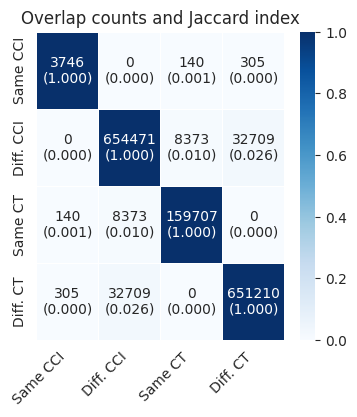

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Prepare annotation text (count + jaccard)
annot = np.empty_like(overlap.values).astype(object)

for i in range(overlap.shape[0]):
    for j in range(overlap.shape[1]):
        annot[i, j] = f"{int(overlap.iloc[i, j])}\n({jaccard.iloc[i, j]:.3f})"

plt.figure(figsize=(4, 4))

ax = sns.heatmap(
    jaccard.astype(float),
    annot=annot,
    fmt="",
    cmap="Blues",
    cbar=True,
    linewidths=0.5
)

plt.xticks(rotation=45, ha="right")
plt.title("Overlap counts and Jaccard index")

plt.savefig('/home/lnemati/pathway_crosstalk/results/revision/images/contingency_same_diff_cci_ct.pdf', dpi=300, bbox_inches='tight')
plt.savefig('/home/lnemati/pathway_crosstalk/results/revision/images/contingency_same_diff_cci_ct.png', dpi=300, bbox_inches='tight')


plt.show()

In [10]:
ccc = pd.read_csv('/home/lnemati/pathway_crosstalk/data/interactions/ccc_lr_pairs.csv')
ct = pd.read_csv('/home/lnemati/pathway_crosstalk/data/interactions/same_cell_type_same_organ_dedup.csv', index_col=0)

ccc_pairs = set(ccc['all_genes'].apply(lambda x: tuple(sorted(literal_eval(x)))))
ct_pairs = set(ct['all_genes'].apply(lambda x: tuple(sorted(literal_eval(x)))))

intersection = ccc_pairs & ct_pairs
union = ccc_pairs | ct_pairs

# considering only ccc genes
ligands = set(ccc['ligand'])
receptors = set(ccc['receptor'])
ccc_genes = ligands | receptors

ct_pairs_filtered = {
    pair for pair in ct_pairs
    if (
        pair[0] in ccc_genes and pair[1] in ccc_genes and
        (
            (pair[0] in ligands and pair[1] in receptors) or
            (pair[0] in receptors and pair[1] in ligands)
        )
    )
}

intersection_ccc_ct = ccc_pairs & ct_pairs_filtered
union_ccc_ct = ccc_pairs | ct_pairs_filtered

print(f'{len(intersection_ccc_ct)} LR pairs out of {len(ccc_pairs)} are markers of same cell type')

140 LR pairs out of 3746 are markers of same cell type


In [11]:
140/3746

0.03737319807794982

In [12]:
from ast import literal_eval
from itertools import chain

ct_genes = set(chain.from_iterable(
    literal_eval(x) for x in ct['all_genes']
))

In [15]:
len(ct_genes.intersection(ccc_genes))

791

In [16]:
len(ct_genes.union(ccc_genes))

3856

# Survival

In [119]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
#from matplotlib.legend_handler import HandlerBase
import os
import numpy as np
#import scanpy as sc
#import PyWGCNA
#import seaborn as sns
#from sklearn.metrics import roc_curve, roc_auc_score
#from scipy.stats import mannwhitneyu, false_discovery_control
import re
from itertools import combinations
from scipy.stats import pearsonr, spearmanr
import ast
from matplotlib import patches
#from lifelines import KaplanMeierFitter
#from lifelines.statistics import logrank_test
#from lifelines.plotting import add_at_risk_counts
import matplotlib.patheffects as path_effects  # Import PathEffects for text outlines
from matplotlib.gridspec import GridSpec

In [120]:
rawdf = pd.read_csv('/home/lnemati/pathway_crosstalk/results/survival/aggregate/all_unfiltered.csv')
crosstalkdf = pd.read_csv('/home/lnemati/pathway_crosstalk/results/survival/aggregate/all_pairs.csv')

significant = crosstalkdf.query('pval_adj < 0.05')
significant = significant.query('not ((hr - se) < 1 and 1 < (hr + se))')

better = significant.copy()
better = better.query('hr_lfc_best > 0.')
better = better.query('c_diff_best > 0.')
better = better.query('(logrank_pval < logrank_pval1) and (logrank_pval < logrank_pval2)')

cliques = better.query('tissue != "Pan_Cancer" and motif in ["3_clique", "4_clique"]')

better.head(3)

,interaction,tissue,hr,hr1,hr2,concordance_index,concordance_index1,concordance_index2,logrank_pval,logrank_pval1,...,min_patients,min_patients1,min_patients2,log2_hr,log2_hr1,log2_hr2,pval_adj,hr_lfc_best,c_diff_best,motif
0,ADA+ADORA2B&FBN1+ITGA5_ITGB1,Pan_Cancer,2.473422,1.449832,1.453431,0.525176,0.520904,0.522021,1.996489e-290,2.866094e-192,...,46629,112035,101772,1.306508,0.535886,0.539462,1.599185e-284,0.767046,0.003155,4_path
1,COL6A3+ITGA10_ITGB1&ADA+ADORA2B,Pan_Cancer,2.690729,1.434415,1.449832,0.522922,0.516268,0.520904,2.855622e-255,2.507191e-171,...,29337,76494,112035,1.427997,0.520463,0.535886,1.143675e-249,0.892112,0.002018,4_no_crosstalk
2,FN1+ITGA11_ITGB1&ADA+ADORA2B,Pan_Cancer,2.452652,1.395628,1.449832,0.526302,0.520509,0.520904,1.348607e-251,3.625836e-201,...,37092,93621,112035,1.294343,0.480914,0.535886,3.600776e-246,0.758457,0.005398,4_no_crosstalk


In [121]:
df = pd.read_csv('/home/lnemati/pathway_crosstalk/results/crosstalk/all_ccc_complex_pairs/adj/motifs/tumor/motifs_permutations.csv')
motifs = pd.read_csv('/home/lnemati/pathway_crosstalk/results/crosstalk/all_ccc_complex_pairs/adj/motifs/tumor/counts.csv', index_col='motif')
motifs = motifs['number'] 

df3 = df[[col for col in df.columns if col.startswith('3')]]
df4 = df[[col for col in df.columns if col.startswith('4')]]
motifs3 = motifs.loc[[idx for idx in motifs.index if idx.startswith('3')]]
motifs4 = motifs.loc[[idx for idx in motifs.index if idx.startswith('4')]]

motifs3 = motifs3 / motifs3.sum()
motifs4 = motifs4 / motifs4.sum()
df3 = (df3.T / df3.sum(1)).T
df4 = (df4.T / df4.sum(1)).T

df = df3.join(df4)
motifs = pd.concat([motifs3, motifs4])

means = df.mean()
stds = df.std()

motifs_z = ((motifs - means) / stds).sort_values()
motifs_z.name = 'z'

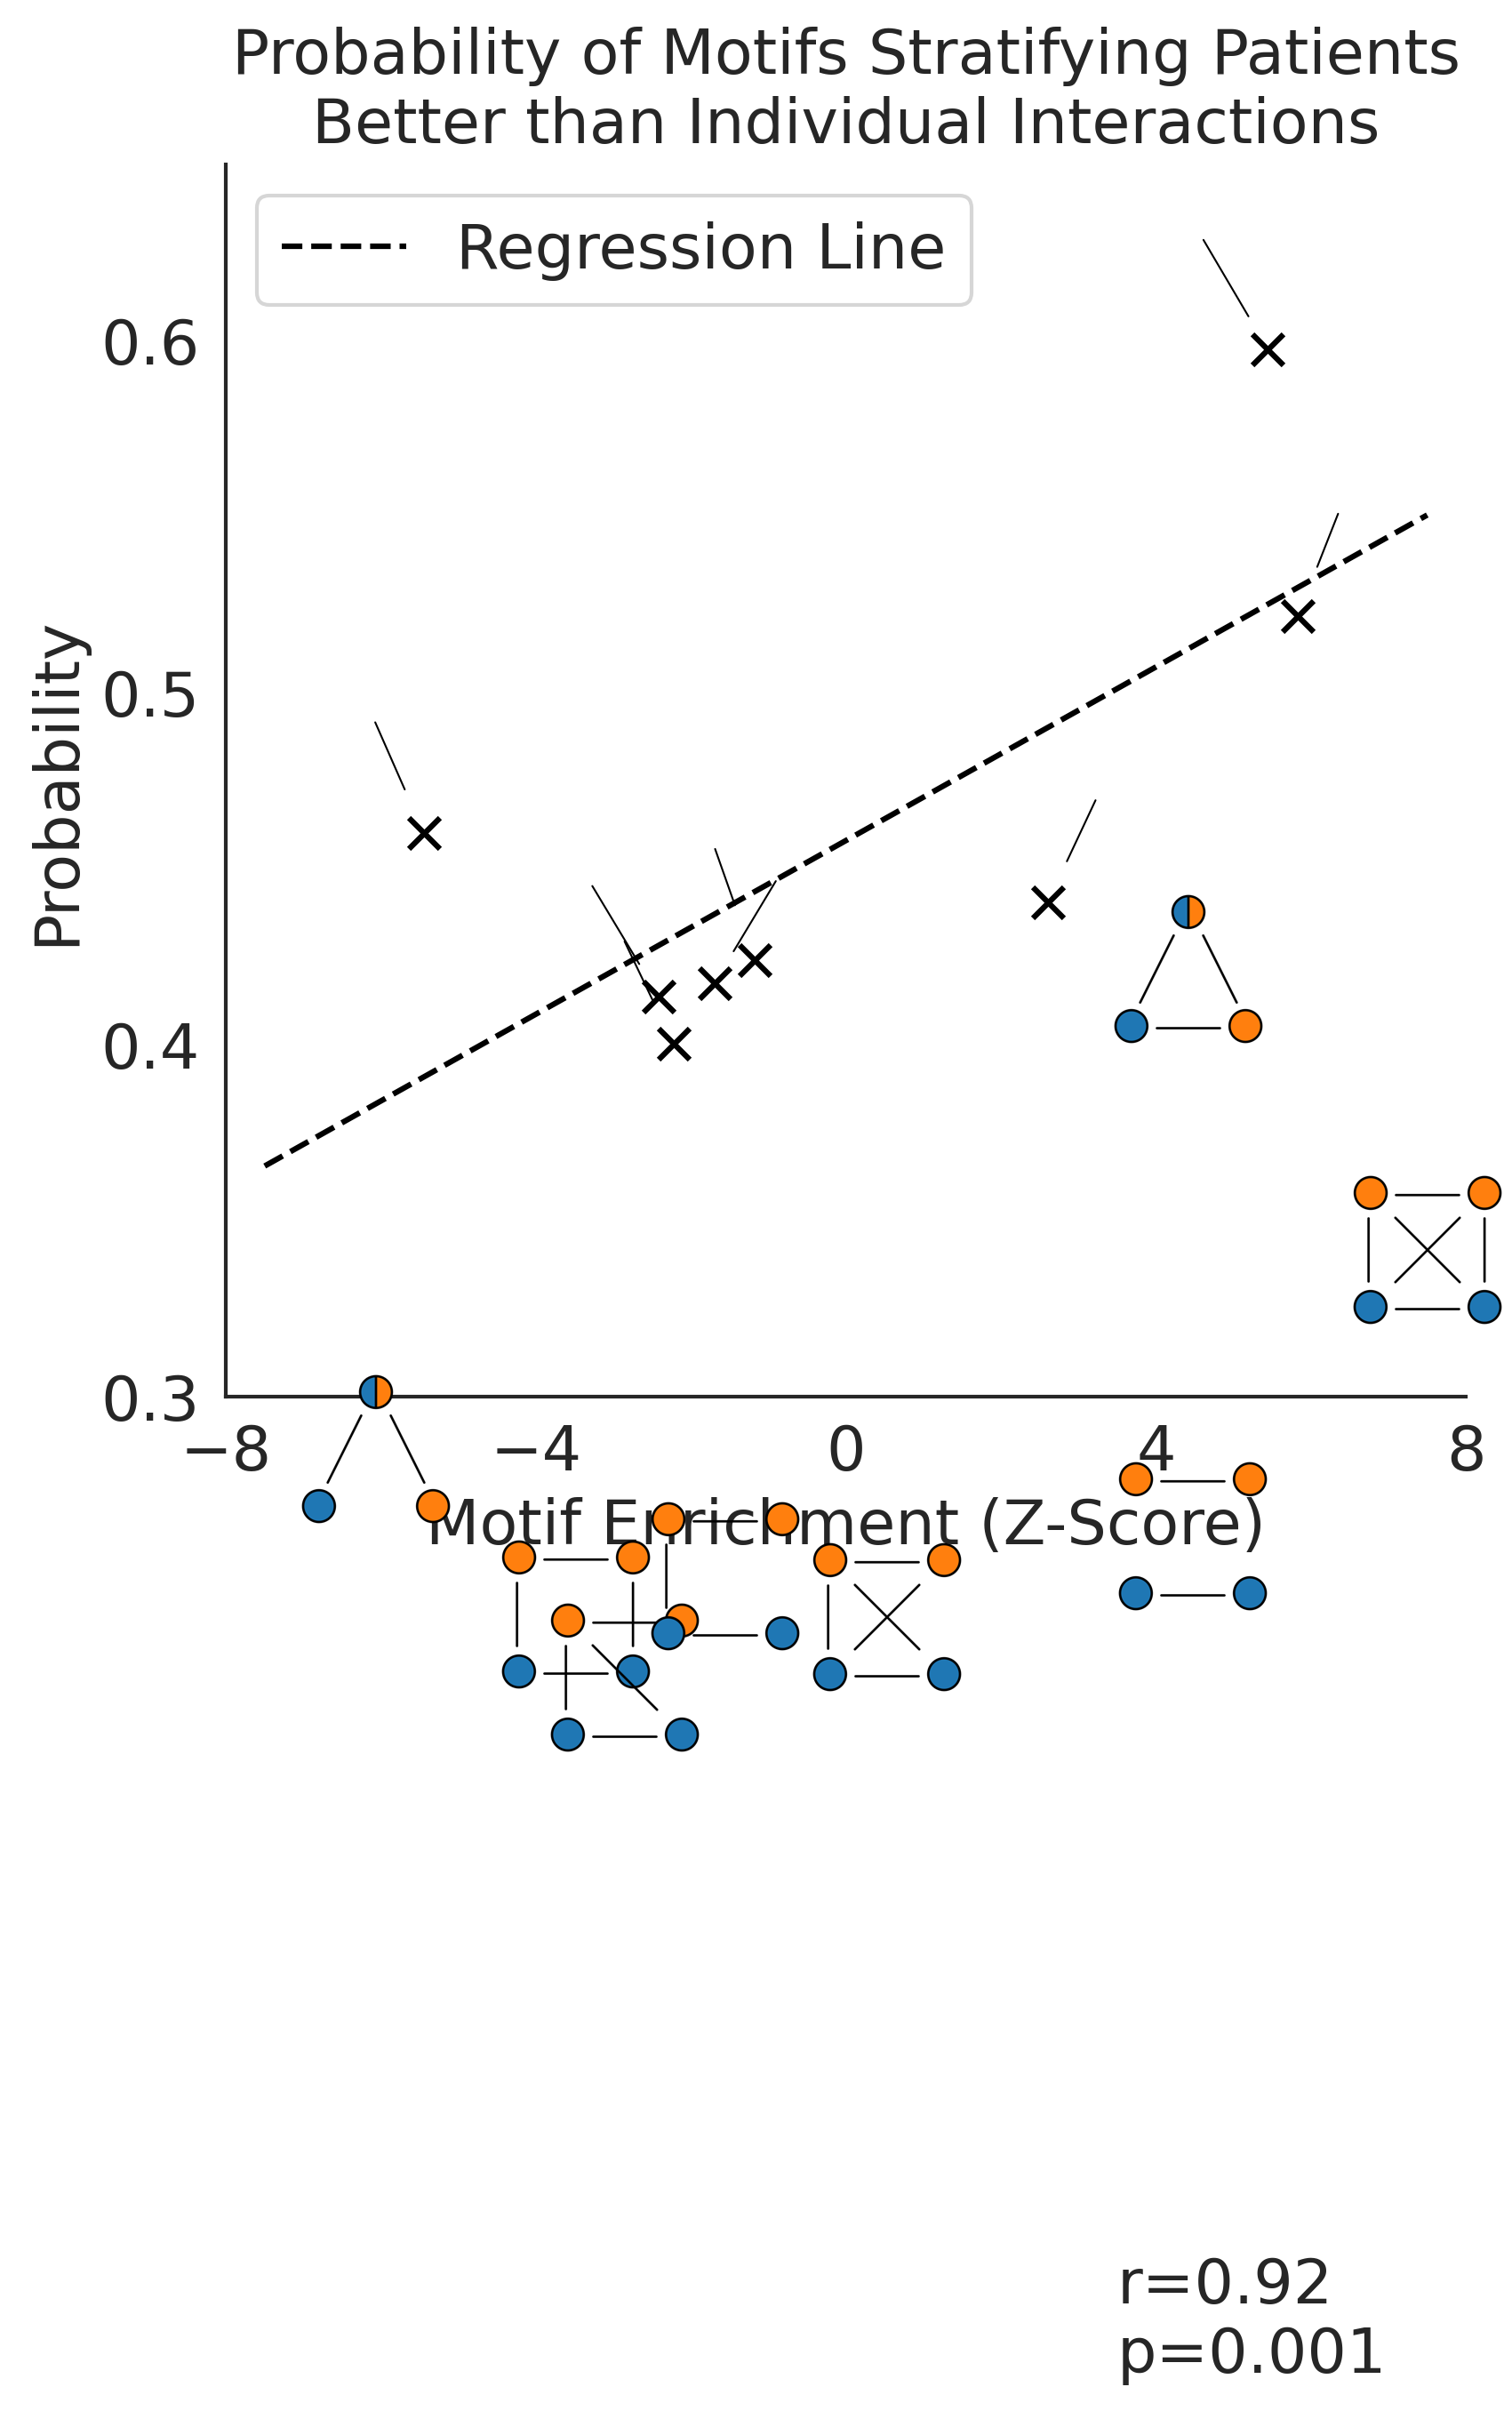

In [142]:
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib import image as mpimg
import os
from PIL import Image

# Constants
dpi = 300
img_dir = '/home/lnemati/pathway_crosstalk/data/motifs_icons/'  # Update this path
image_scaling_factor = 0.3  # Adjust this factor to scale image size (smaller = more zoomed out)
x_offset = -25
y_offset = 250

fs = 14/5 * 6

# Filter data
df = better.query('tissue != "Pan_Cancer"')
#all_counts = crosstalkdf.query('tissue != "Pan_Cancer"').motif.value_counts().sort_values(ascending=False)
#
## Calculate probabilities
#probs = (df.motif.value_counts() / all_counts).sort_values()
#probs = probs.loc[motifs_z.index]

# Count if significant in at least one tissue instead of counting tissues
numerator = df[['interaction', 'motif']].drop_duplicates()['motif'].value_counts()
denominator = crosstalkdf.query('tissue != "Pan_Cancer"')[['interaction', 'motif']].drop_duplicates()['motif'].value_counts()

probs = (numerator / denominator).sort_values()

data = pd.DataFrame()
data['z'] = motifs_z
data['prob'] = probs

# Calculate Pearson correlation
r_value, p_r_value = pearsonr(probs, motifs_z)
rho_value, p_rho_value = spearmanr(probs, motifs_z)

# Create the plot
fig, ax = plt.subplots(1, 1, figsize=(6, 6), dpi=dpi)


ax.scatter(
    data['z'], 
    data['prob'], 
    #color='black', 
    color='black', 
    marker='x', 
    edgecolors='black',  # Black edge color
    s=70,
    linewidths=1.5  # Thickness of the edge
)

# Add Pearson correlation to plot
ax.text(3.5, 0.023, 'r={:.2f}\np={:.3f}'.format(r_value, p_r_value), fontsize=fs)
#ax.text(7, 0.0225, fr"Spearman's $\rho$ = {rho_value:.2f}" + '\n' + f'p-value = {p_rho_value:.2f}', fontsize=fs, ha='right')

# Set limits and ticks
ax.set_xlim(-8, 8)
ax.set_ylim(0.4, 0.65)
xticks = [-8, -4, 0, 4, 8]
yticks = [0.3, 0.4, 0.5, 0.6,]
ax.set_xticks(xticks)
ax.set_yticks(yticks)

# Hide top and right spines
ax.spines[['right', 'top']].set_visible(False)
ax.tick_params(labelsize=fs)

# Add title and labels
ax.set_title('Probability of Motifs Stratifying Patients\nBetter than Individual Interactions', fontsize=fs)
ax.set_xlabel('Motif Enrichment (Z-Score)', fontsize=fs)
ax.set_ylabel('Probability', fontsize=fs)

# Make the background of the plot transparent so the images can show up
ax.patch.set_alpha(0)

# Get the regression line parameters (slope and intercept)
slope, intercept = np.polyfit(data['z'], data['prob'], 1)

# Extend the regression line beyond the data range
x_extended = np.linspace(ax.get_xlim()[0] + 0.5, ax.get_xlim()[1] - 0.5, 100)
y_extended = slope * x_extended + intercept
ax.plot(x_extended, y_extended, linestyle='--', color='k', linewidth=1.5, label='Regression Line', zorder=-10)

# Dictionary to define manual positions for each motif
motif_positions = {
    '3_path': (data['z']['3_path'], data['prob']['3_path']),
    '4_cycle': (data['z']['4_cycle']-0.45, data['prob']['4_cycle']-0.0005),
    '4_triangle_extra': (data['z']['4_triangle_extra'], data['prob']['4_triangle_extra']-0.005),
    '4_one_missing': (data['z']['4_one_missing']+2.85, data['prob']['4_one_missing']-0.005),
    '4_path': (data['z']['4_path']+0.25, data['prob']['4_path']),
    '4_no_crosstalk': (data['z']['4_no_crosstalk']+2.5, data['prob']['4_no_crosstalk']-0.005),
    '3_clique': (data['z']['3_clique']-0.4, data['prob']['3_clique']-0.001),
    '4_clique': (data['z']['4_clique']+2.3, data['prob']['4_clique']-0.005),
}

# Loop through each motif and place an image at the manually defined position
for motif, (x_pos, y_pos) in motif_positions.items():
    img_path = os.path.join(img_dir, f"{motif}.png")
    if os.path.exists(img_path):
        # Read image
        im = Image.open(img_path)
        
        # Resize the image (scale it down by the factor)
        width, height = im.size
        im_resized = im.resize((int(width * image_scaling_factor), int(height * image_scaling_factor)))

        # Convert resized image to numpy array for figimage
        im_resized = np.array(im_resized)

        # Transform plot coordinates to pixel coordinates
        pixel_pos = ax.transData.transform((x_pos, y_pos))
        
        # Place image at position (centered over the point) with scaled size
        fig.figimage(
            im_resized,
            pixel_pos[0] - im_resized.shape[1] / 2 + x_offset,
            pixel_pos[1] - im_resized.shape[0] / 2 + y_offset, 
            origin="upper"
        )

        line_frac = 0.5  # Fraction to remove from the image (icon) side
        marker_trim = 0.25  # Fixed distance to trim from the marker side (in data units)

        # Compute image center in pixel space
        img_center_x_pix = pixel_pos[0] - im_resized.shape[1] / 2 + x_offset
        img_center_y_pix = pixel_pos[1] + y_offset

        # Convert image center from pixel to data coordinates
        img_center_data = ax.transData.inverted().transform((img_center_x_pix, img_center_y_pix))

        # Coordinates of the start (marker) and end (image) of the full line
        x0, y0 = motifs_z.loc[motif], probs.loc[motif]  # marker
        x1, y1 = img_center_data                        # image

        # Vector from marker to image
        dx = x1 - x0
        dy = y1 - y0
        line_length = np.hypot(dx, dy)

        # Normalize direction vector
        dxn, dyn = dx / line_length, dy / line_length

        # Remove a fixed-length segment from the marker side
        x_start = x0 + dxn * marker_trim
        y_start = y0 + dyn * marker_trim

        # Remove a *fraction* of the total line length from the image side
        x_end = x1 - dxn * (line_frac * line_length)
        y_end = y1 - dyn * (line_frac * line_length)

        # Draw the trimmed line
        ax.plot([x_start, x_end], [y_start, y_end], color='k', linewidth=0.5, zorder=-5)

# Hide legend, as it may conflict with the images
#plt.legend([], [], frameon=False)
plt.legend(fontsize=fs, loc='upper left')

#plt.savefig('/home/lnemati/pathway_crosstalk/results/revision/figures/survival/motifs_z_prob.pdf', bbox_inches='tight', dpi=dpi)
#plt.savefig('/home/lnemati/pathway_crosstalk/results/revision/figures/survival/motifs_z_prob.png', bbox_inches='tight', dpi=dpi)

# Show the plot
plt.show()


# Same Module

In [3]:
tissues_df = pd.read_csv('/home/lnemati/pathway_crosstalk/data/tissues.csv')

In [4]:
import os
import pandas as pd

module_dfs = []

for idx, row in tissues_df.iterrows():
    try:
        wgcna_file = 'wgcna_' + row.path.split('/')[-1] + '.p'
        wgcna_file = os.path.join(row['path'], wgcna_file)

        wgcna = PyWGCNA.readWGCNA(wgcna_file)
        modules = wgcna.datExpr.var['moduleLabels']

        # ensure it's a Series
        modules = pd.Series(modules, dtype="Int64")
        modules.name = row['subtissue']

        module_dfs.append(modules)

    except Exception as e:
        print('skipped:', row['subtissue'], '| reason:', e)


# Combine all subtissues into one DataFrame (aligns on index automatically)
modules_df = pd.concat(module_dfs, axis=1)

Reading wgcna_rectum_adenocarcinoma WGCNA done!
Reading wgcna_uterine_carcinosarcoma WGCNA done!
Reading wgcna_thyroid_carcinoma WGCNA done!
Reading wgcna_kidney_papillary_cell_carcinoma WGCNA done!
Reading wgcna_kidney_chromophobe WGCNA done!
Reading wgcna_kidney_clear_cell_carcinoma WGCNA done!
Reading wgcna_brain_lower_grade_glioma WGCNA done!
Reading wgcna_glioblastoma_multiforme WGCNA done!
Reading wgcna_adrenocortical_cancer WGCNA done!
Reading wgcna_testicular_germ_cell_tumor WGCNA done!
Reading wgcna_liver_hepatocellular_carcinoma WGCNA done!
Reading wgcna_prostate_adenocarcinoma WGCNA done!
Reading wgcna_thymoma WGCNA done!
Reading wgcna_lung_squamous_cell_carcinoma WGCNA done!
Reading wgcna_lung_adenocarcinoma WGCNA done!
Reading wgcna_bladder_urothelial_carcinoma WGCNA done!
Reading wgcna_breast_invasive_carcinoma WGCNA done!
Reading wgcna_cervical_and_endocervical_cancer WGCNA done!
Reading wgcna_ovarian_serous_cystadenocarcinoma WGCNA done!
Reading wgcna_uterine_corpus_end

In [5]:
modules_df.head()

,rectum_adenocarcinoma,uterine_carcinosarcoma,thyroid_carcinoma,kidney_papillary_cell_carcinoma,kidney_chromophobe,kidney_clear_cell_carcinoma,brain_lower_grade_glioma,glioblastoma_multiforme,adrenocortical_cancer,testicular_germ_cell_tumor,...,thyroid,pituitary,small_intestine_terminal_ileum,colon_sigmoid,colon_transverse,spleen,esophagus_gastroesophageal_junction,esophagus_muscularis,esophagus_mucosa,stomach
RAB4B,17,18,3,9,4,3,10,5,7,0,...,22,5,7,0,0,21,9,21,2,0
TIGAR,6,30,0,13,1,5,10,5,16,3,...,25,8,0,5,3,4,8,12,2,3
RNF44,7,14,1,13,2,5,7,3,7,3,...,14,5,7,0,0,17,15,8,9,0
DNAH3,15,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,7,...,<NA>,5,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
RPL23A,14,26,8,4,2,6,4,7,3,9,...,2,8,5,0,1,10,11,7,7,1


In [6]:
modules_df.to_csv('/home/lnemati/pathway_crosstalk/results/comparison/modules_all_gene_all_tissues.csv')

In [118]:
modules_df = pd.read_csv('/home/lnemati/pathway_crosstalk/results/comparison/modules_all_gene_all_tissues.csv', index_col=0)

ccc = pd.read_csv('/home/lnemati/pathway_crosstalk/data/interactions/ccc.csv')
ccc['all_genes'] = ccc['all_genes'].apply(literal_eval)

cci_genes = list(set(ccc['all_genes'].sum()))

t_tissues = list(tissues_df.query('condition == "tumor"')['subtissue'])
n_tissues = list(tissues_df.query('condition == "normal"')['subtissue'])

t_modules = modules_df[[t for t in t_tissues if t in modules_df.columns]]
n_modules = modules_df[[n for n in n_tissues if n in modules_df.columns]]

# Subset to only CCI genes
t_modules = t_modules.loc[[g for g in cci_genes if g in t_modules.index]]
n_modules = n_modules.loc[[g for g in cci_genes if g in n_modules.index]]

In [115]:
import pandas as pd
import numpy as np
from tqdm import tqdm

# -------------------------
# FORCE FLOAT MATRICES
# -------------------------
t_mat = t_modules.to_numpy(dtype=float)
n_mat = n_modules.to_numpy(dtype=float)

gene_to_t_idx = {g: i for i, g in enumerate(t_modules.index)}
gene_to_n_idx = {g: i for i, g in enumerate(n_modules.index)}

# -------------------------
# FAST FUNCTION
# -------------------------
def has_same_module(mat, row_idx):
    sub = mat[row_idx, :]

    valid_cols = ~np.isnan(sub).any(axis=0)
    if not np.any(valid_cols):
        return False

    sub = sub[:, valid_cols]
    return np.any(np.ptp(sub, axis=0) == 0)

# -------------------------
# OBSERVED VALUES
# -------------------------
results = []

for genes in ccc['all_genes']:

    genes = list(genes)

    t_idx = [gene_to_t_idx[g] for g in genes if g in gene_to_t_idx]
    n_idx = [gene_to_n_idx[g] for g in genes if g in gene_to_n_idx]

    t_same_module = False
    n_same_module = False

    if len(t_idx) == len(genes):
        t_same_module = has_same_module(t_mat, np.array(t_idx))

    if len(n_idx) == len(genes):
        n_same_module = has_same_module(n_mat, np.array(n_idx))

    results.append({
        "genes": genes,
        "tumor_same_module": t_same_module,
        "normal_same_module": n_same_module
    })

results_df = pd.DataFrame(results)

obs_N_t = results_df['tumor_same_module'].sum()
obs_N_n = results_df['normal_same_module'].sum()
obs_N_both = (results_df['tumor_same_module'] &
              results_df['normal_same_module']).sum()

print("Observed:")
print("Tumor:", obs_N_t)
print("Normal:", obs_N_n)
print("Both:", obs_N_both)

# -------------------------
# PERMUTATION TEST
# -------------------------
n_perm = 100

perm_N_t = np.zeros(n_perm)
perm_N_n = np.zeros(n_perm)
perm_N_both = np.zeros(n_perm)

rng = np.random.default_rng()

for p in tqdm(range(n_perm), desc="Permutations"):

    # shuffle each column independently
    t_perm = np.apply_along_axis(rng.permutation, 0, t_mat)
    n_perm_mat = np.apply_along_axis(rng.permutation, 0, n_mat)

    perm_t = []
    perm_n = []

    for genes in ccc['all_genes']:

        genes = list(genes)

        t_idx = [gene_to_t_idx[g] for g in genes if g in gene_to_t_idx]
        n_idx = [gene_to_n_idx[g] for g in genes if g in gene_to_n_idx]

        t_same_module = False
        n_same_module = False

        if len(t_idx) == len(genes):
            t_same_module = has_same_module(t_perm, np.array(t_idx))

        if len(n_idx) == len(genes):
            n_same_module = has_same_module(n_perm_mat, np.array(n_idx))

        perm_t.append(t_same_module)
        perm_n.append(n_same_module)

    perm_t = np.array(perm_t)
    perm_n = np.array(perm_n)

    perm_N_t[p] = perm_t.sum()
    perm_N_n[p] = perm_n.sum()
    perm_N_both[p] = (perm_t & perm_n).sum()

# -------------------------
# P-VALUES
# -------------------------
p_t = (np.sum(perm_N_t >= obs_N_t) + 1) / (n_perm + 1)
p_n = (np.sum(perm_N_n >= obs_N_n) + 1) / (n_perm + 1)
p_both = (np.sum(perm_N_both >= obs_N_both) + 1) / (n_perm + 1)

print("\nEmpirical p-values:")
print("Tumor:", p_t)
print("Normal:", p_n)
print("Both:", p_both)

Observed:
Tumor: 2301
Normal: 2794
Both: 2065


Permutations: 100%|██████████| 100/100 [00:18<00:00,  5.30it/s]


Empirical p-values:
Tumor: 0.009900990099009901
Normal: 0.009900990099009901
Both: 0.009900990099009901


# Processes Enrichment


In [83]:
import re
import os
from itertools import combinations
from ast import literal_eval
from tqdm import tqdm

In [63]:
# Read cliques
cliques = pd.read_csv(
    '/home/lnemati/pathway_crosstalk/results/crosstalk/all_ccc_complex_pairs/adj/motifs/tumor/cliques_with_hallmarks.csv',
    index_col=0
)
cliques['all_genes'] =  cliques['all_genes'].apply(literal_eval)
# Get observed occurrences of hallmarks
observed = cliques.iloc[:, 5:].sum()

# Read all CCI pairs for random pairs sampling
all_cci_pairs = pd.read_csv('/home/lnemati/pathway_crosstalk/data/interactions/pairs_of_interactions.csv')
all_cci_pairs['all_genes'] =  all_cci_pairs['all_genes'].apply(literal_eval)


In [78]:
import pandas as pd
import re

# Load hallmark gene sets
def read_gmt(file_path):
    gene_sets = {}
    with open(file_path, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) >= 3:
                gene_sets[parts[0]] = set(parts[2:])
    return gene_sets

# Load hallmark data
hallmarks_path = '/home/lnemati/resources/msigdb_hallmarks/h.all.v2024.1.Hs.symbols.gmt'
hallmarks = read_gmt(hallmarks_path)

# Generate readable labels
labels = [label.replace('HALLMARK_', '').replace('_', ' ').title() for label in hallmarks.keys()]

# Mapping for special formatting
replace = {
    'Myc': 'MYC',
    'Kras': 'KRAS',
    'Il2': 'IL2',
    'Stat5': 'STAT5',
    'Il6': 'IL6',
    'Jak': 'JAK',
    'Stat3': 'STAT3',
    'P53': 'P53',
    'Tnfa': 'TNFα',
    'Nfkb': 'NF-κB',
    'Mtorc1': 'MTORC1',
    ' Dn': ' Down',
    'Epithelial Mesenchymal Transition': 'E-M Transition'
}

# Apply replacements to labels
for str1, str2 in replace.items():
    labels = [label.replace(str1, str2) for label in labels]

# Map original hallmark names to cleaned labels
hallmark_name_map = dict(zip(hallmarks.keys(), labels))

In [103]:
N_PERMS = 1000
permutations = pd.DataFrame(
    np.zeros((N_PERMS, len(labels))),
    columns=labels
)

for seed in tqdm(range(N_PERMS)):
    
    sampled_pairs = all_cci_pairs.sample(n=len(cliques), random_state=seed)

    # Identify overlapping hallmark names (original form)
    def find_matching_hallmarks(gene_list, hallmark_sets):
        return [name for name, genes in hallmark_sets.items() if set(gene_list) & genes]

    # Assign original hallmark names per row
    sampled_pairs['hallmarks'] = sampled_pairs['all_genes'].apply(lambda genes: find_matching_hallmarks(genes, hallmarks))

    # Convert to readable labels
    sampled_pairs['hallmarks'] = sampled_pairs['hallmarks'].apply(
        lambda hlist: [hallmark_name_map[h] for h in hlist]
    )

    # Extract all hallmark
    all_hallmarks = sorted(set(sum(sampled_pairs['hallmarks'], [])))

    # Add True/False column for each readable hallmark label
    for label in all_hallmarks:
        sampled_pairs[label] = sampled_pairs['hallmarks'].apply(lambda x: label in x)
        
    counts = sampled_pairs.iloc[:, 5:].sum()
    permutations.loc[seed, counts.index] = counts.values

100%|██████████| 1000/1000 [11:06<00:00,  1.50it/s]


In [104]:
mean = permutations.mean()
std = permutations.std()

z = (observed - mean) / std

In [106]:
z.sort_values()

Fatty Acid Metabolism              -22.748854
P53 Pathway                        -22.088324
Wnt Beta Catenin Signaling         -21.950234
Xenobiotic Metabolism              -21.194424
Notch Signaling                    -19.377240
Uv Response Down                   -16.701009
Estrogen Response Early            -14.471153
Estrogen Response Late             -13.779236
Glycolysis                         -12.409612
E-M Transition                     -12.179564
Uv Response Up                     -11.552285
Tgf Beta Signaling                 -11.524920
Hedgehog Signaling                 -11.489943
Hypoxia                            -11.288029
Androgen Response                  -10.307104
Peroxisome                         -10.231399
Angiogenesis                        -8.179867
Adipogenesis                        -7.120954
G2M Checkpoint                      -6.680682
Cholesterol Homeostasis             -6.596320
KRAS Signaling Down                 -4.382313
Bile Acid Metabolism              

In [5]:
cliques

,Type,Interaction,density,all_genes,hallmarks,Adipogenesis,Allograft Rejection,Androgen Response,Angiogenesis,Apical Junction,...,Peroxisome,Pi3K Akt Mtor Signaling,Protein Secretion,TNFα Signaling Via NF-κB,Tgf Beta Signaling,Unfolded Protein Response,Uv Response Down,Uv Response Up,Wnt Beta Catenin Signaling,Xenobiotic Metabolism
0,3_clique,CCL3+CCR1&CCL5+CCR1,0.788580,"['CCL3', 'CCR1', 'CCL5', 'CCR1']","['Allograft Rejection', 'Complement', 'IL6 JAK...",False,True,False,False,False,...,False,False,False,True,False,False,False,False,False,False
1,3_clique,CD4+HLA-DQA2&CD4+IL16,0.769731,"['CD4', 'HLA-DQA2', 'CD4', 'IL16']",['Allograft Rejection'],False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3_clique,CCL3+CCR1&CCL3+CCR5,0.765212,"['CCL3', 'CCR1', 'CCL3', 'CCR5']","['Allograft Rejection', 'IL6 JAK STAT3 Signali...",False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,3_clique,CCL5+CCR1&CCL5+CCR5,0.763448,"['CCL5', 'CCR1', 'CCL5', 'CCR5']","['Allograft Rejection', 'Complement', 'IL6 JAK...",False,True,False,False,False,...,False,False,False,True,False,False,False,False,False,False
4,3_clique,CD4+HLA-DQA2&CD4+HLA-DRB5,0.762346,"['CD4', 'HLA-DQA2', 'CD4', 'HLA-DRB5']",['Allograft Rejection'],False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4750,4_clique,COL5A3+ITGA11_ITGB1&CD80+CTLA4,0.700838,"['COL5A3', 'ITGA11', 'ITGB1', 'CD80', 'CTLA4']","['Allograft Rejection', 'Apical Junction', 'E-...",False,True,False,False,True,...,False,False,False,True,False,False,False,False,False,False
4751,4_clique,CD80+CTLA4&FN1+ITGA11_ITGB1,0.697751,"['CD80', 'CTLA4', 'FN1', 'ITGA11', 'ITGB1']","['Allograft Rejection', 'Apical Junction', 'Co...",False,True,False,False,True,...,False,False,False,True,False,False,False,False,False,False
4752,4_clique,COL12A1+ITGA11_ITGB1&CD80+CTLA4,0.697090,"['COL12A1', 'ITGA11', 'ITGB1', 'CD80', 'CTLA4']","['Allograft Rejection', 'Apical Junction', 'E-...",False,True,False,False,True,...,False,False,False,True,False,False,False,False,False,False
4753,4_clique,COL10A1+ITGA10_ITGB1&TNFRSF11B+TNFSF11,0.696649,"['COL10A1', 'ITGA10', 'ITGB1', 'TNFRSF11B', 'T...","['Apical Junction', 'E-M Transition', 'IL2 STA...",False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
